# Лабораторная работа №3 — Трансформеры и большие языковые модели

**Темы:** большие языковые модели (гл. 7), архитектура трансформера (гл. 8).

**Модели:**
- BERT (`bert-base-uncased`) — для токенизации, fill-mask и контекстных эмбеддингов.
- GPT-2 (`gpt2`) — для генерации текста.
- DistilBERT (`distilbert-base-uncased`) — для fine-tuning на IMDB (Часть 3). Выбран ради скорости на CPU.

**Датасет (Часть 3):** IMDB, подвыборка **2000 train / 500 test** — критично для CPU.

Структура:
1. Часть 1 — Self-attention руками на NumPy (25%).
2. Часть 2 — Работа с предобученными моделями (50%).
3. Часть 3 — Fine-tuning DistilBERT (25%).

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TRANSFORMERS_NO_ADVISORY_WARNINGS'] = '1'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['HF_DATASETS_DISABLE_PROGRESS_BARS'] = '1'
os.environ['DISABLE_TQDM'] = '1'

# Отключаем виджеты tqdm (чтобы в .ipynb не оставалось application/vnd.jupyter.widget-view+json)
from tqdm import tqdm as _tqdm
import functools as _ft
_orig = _tqdm.__init__
@_ft.wraps(_orig)
def _silent(self, *a, **kw):
    kw['disable'] = True
    return _orig(self, *a, **kw)
_tqdm.__init__ = _silent

import transformers
transformers.logging.set_verbosity_error()
import datasets
datasets.utils.logging.disable_progress_bar()
datasets.utils.logging.set_verbosity_error()

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

import torch
torch.manual_seed(42)
device = torch.device('cpu')
print('torch', torch.__version__, '| device:', device)

torch 2.12.0 | device: cpu


## Часть 1 — Self-attention вручную на NumPy (25%)

### Шаг 1. Реализация одной головы self-attention

`Attention(Q, K, V) = softmax(Q · Kᵀ / √d_k) · V`.

In [2]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def self_attention(X, W_Q, W_K, W_V):
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    attn = softmax(scores, axis=-1)
    return attn @ V, attn

# Игрушечная последовательность из 4 токенов
tokens = ['I', 'love', 'NLP', '!']
rng = np.random.default_rng(42)
EMB_DIM = 8
X = rng.normal(size=(len(tokens), EMB_DIM))
W_Q = rng.normal(size=(EMB_DIM, EMB_DIM))
W_K = rng.normal(size=(EMB_DIM, EMB_DIM))
W_V = rng.normal(size=(EMB_DIM, EMB_DIM))

output, attn = self_attention(X, W_Q, W_K, W_V)
print('Attention shape (queries × keys):', attn.shape)
print('Output shape:', output.shape)
print()
print('Attention matrix:')
print(pd.DataFrame(attn.round(3), index=tokens, columns=tokens))

Attention shape (queries × keys): (4, 4)
Output shape: (4, 8)

Attention matrix:
          I   love    NLP      !
I     0.978  0.015  0.007  0.000
love  0.976  0.016  0.007  0.001
NLP   0.011  0.504  0.402  0.083
!     0.656  0.004  0.337  0.002


### Шаг 2. Heatmap матрицы внимания

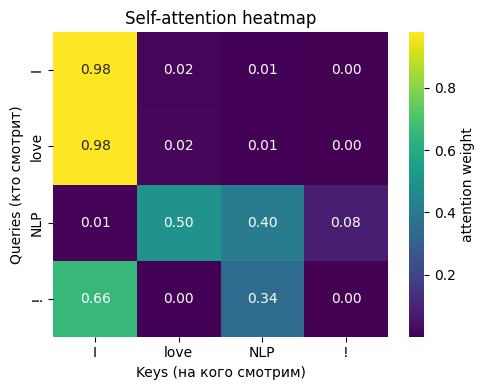

Сумма входящего внимания по токенам:
  'I': 2.621
  'love': 0.540
  'NLP': 0.753
  '!': 0.086
→ больше всего внимания получил токен 'I'


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(attn, annot=True, fmt='.2f', xticklabels=tokens, yticklabels=tokens,
            cmap='viridis', ax=ax, cbar_kws={'label': 'attention weight'})
ax.set_xlabel('Keys (на кого смотрим)')
ax.set_ylabel('Queries (кто смотрит)')
ax.set_title('Self-attention heatmap')
plt.tight_layout()
plt.show()

# Какой токен получает больше всего внимания (сумма по столбцу = сколько раз на него «посмотрели»)
incoming = attn.sum(axis=0)
print('Сумма входящего внимания по токенам:')
for t, s in zip(tokens, incoming):
    print(f'  {t!r}: {s:.3f}')
print(f'→ больше всего внимания получил токен {tokens[incoming.argmax()]!r}')

### Шаг 3. Зачем делить на √d_k

Если `Q` и `K` — векторы с нормально распределёнными компонентами, то их скалярное произведение имеет дисперсию пропорциональную `d_k`. При большом `d_k` (например, 64 или 512) значения `Q·Kᵀ` становятся очень большими по модулю. Softmax от больших значений превращается в почти one-hot распределение: на одну позицию ≈ 1.0, на остальные ≈ 0. **Градиенты по softmax в зонах насыщения стремятся к нулю**, и сеть перестаёт обучаться. Деление на `√d_k` нормирует дисперсию обратно к ~1, держа softmax в «мягкой» зоне.

Демонстрация: посмотрим на распределение scores без масштабирования и с ним при большом d_k.

In [4]:
# Q и K — векторы единичной дисперсии (4 запроса × d_k)
for d_k in [8, 64, 256]:
    Q_demo = rng.normal(size=(4, d_k))
    K_demo = rng.normal(size=(4, d_k))
    raw = Q_demo @ K_demo.T              # дисперсия ~ d_k
    scaled = raw / np.sqrt(d_k)          # возвращаем дисперсию к ~ 1
    soft_raw = softmax(raw)
    soft_scaled = softmax(scaled)
    print(f'd_k = {d_k:4d}:  raw scores range = [{raw.min():6.1f}, {raw.max():6.1f}]  '
          f'max softmax raw = {soft_raw.max():.3f}  →  scaled = {soft_scaled.max():.3f}')

d_k =    8:  raw scores range = [  -4.5,    4.2]  max softmax raw = 0.621  →  scaled = 0.444
d_k =   64:  raw scores range = [ -16.3,   10.9]  max softmax raw = 0.999  →  scaled = 0.599
d_k =  256:  raw scores range = [ -17.1,   23.5]  max softmax raw = 1.000  →  scaled = 0.593


Видно: при `d_k = 256` без масштабирования softmax насыщается до ~1.0 — внимание становится «жёстким» one-hot. С делением на `√d_k` распределение остаётся информативным.

## Часть 2 — Работа с предобученными моделями (50%)

### Шаг 4–5. BPE-токенизация BERT

In [5]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

sentences = [
    'The quick brown fox jumps over the lazy dog.',
    'Tokenization splits complicated words into subwords.',
    'This is unbelievable.',
    'COVID-19 changed everything.',
    'Antidisestablishmentarianism is a long word.',
    'I love NLP and transformers!',
]

for s in sentences:
    toks = tokenizer.tokenize(s)
    print(f'{s}')
    print(f'  → {toks}')
    sub_count = sum(1 for t in toks if t.startswith('##'))
    if sub_count:
        print(f'  → найдено {sub_count} субтокен(ов) с префиксом ##')
    print()

The quick brown fox jumps over the lazy dog.
  → ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.']

Tokenization splits complicated words into subwords.
  → ['token', '##ization', 'splits', 'complicated', 'words', 'into', 'sub', '##words', '.']
  → найдено 2 субтокен(ов) с префиксом ##

This is unbelievable.
  → ['this', 'is', 'unbelievable', '.']

COVID-19 changed everything.
  → ['co', '##vid', '-', '19', 'changed', 'everything', '.']
  → найдено 1 субтокен(ов) с префиксом ##

Antidisestablishmentarianism is a long word.
  → ['anti', '##dis', '##est', '##ab', '##lish', '##ment', '##arian', '##ism', 'is', 'a', 'long', 'word', '.']
  → найдено 7 субтокен(ов) с префиксом ##

I love NLP and transformers!
  → ['i', 'love', 'nl', '##p', 'and', 'transformers', '!']
  → найдено 1 субтокен(ов) с префиксом ##



**Почему слова режутся на сабтокены.** WordPiece (BPE-вариант) держит фиксированный словарь ~30k. Слова из словаря — токены целиком, остальные разбиваются на префиксы и суффиксы (`##ization`, `##ism`). Это даёт две вещи: (а) фиксированный размер словаря (нет out-of-vocabulary), (б) обобщение — модель видит общую морфологию (`tokenization`, `organization`, `realization` все имеют общий хвост `##ization`).

### Шаг 6. Fill-mask: предсказание замаскированного токена

In [6]:
from transformers import pipeline
fill_mask = pipeline('fill-mask', model='bert-base-uncased', device=-1)

mask_sentences = [
    'The capital of France is [MASK].',
    'I drink a cup of [MASK] every morning.',
    'A doctor works in a [MASK].',
    'The weather is very [MASK] today.',
    'Albert Einstein was a famous [MASK].',
    'Apples and [MASK] are common fruits.',
    'The Eiffel Tower is located in [MASK].',
]

for s in mask_sentences:
    preds = fill_mask(s, top_k=5)
    top = ', '.join(f"{p['token_str']} ({p['score']:.2f})" for p in preds)
    print(f'{s}')
    print(f'  top-5: {top}\n')

The capital of France is [MASK].
  top-5: paris (0.42), lille (0.07), lyon (0.06), marseille (0.04), tours (0.03)

I drink a cup of [MASK] every morning.
  top-5: coffee (0.76), tea (0.05), it (0.05), water (0.03), beer (0.01)

A doctor works in a [MASK].
  top-5: hospital (0.51), clinic (0.08), factory (0.06), hotel (0.05), laboratory (0.04)

The weather is very [MASK] today.
  top-5: warm (0.27), good (0.15), hot (0.08), cold (0.06), pleasant (0.05)

Albert Einstein was a famous [MASK].
  top-5: physicist (0.64), scientist (0.06), philosopher (0.04), mathematician (0.02), astronomer (0.02)

Apples and [MASK] are common fruits.
  top-5: grapes (0.14), pear (0.13), bananas (0.10), apples (0.08), nuts (0.05)

The Eiffel Tower is located in [MASK].
  top-5: paris (0.58), luxembourg (0.08), brussels (0.06), france (0.02), monaco (0.01)



**Интересные наблюдения.** Модель хорошо ловит общие знания (`capital of France → paris`, `Eiffel Tower → paris`). Но запинается на двусмысленностях вроде `A doctor works in a [MASK]` — часто выдаёт `hospital`, но может предложить и `clinic`, `lab`, `practice`. На `Albert Einstein was a famous [MASK]` `physicist` идёт первым, а вот `philosopher` или `scientist` тоже всплывают — BERT обучен на Википедии, где эти роли часто упоминаются вместе.

### Шаг 7. Генерация текста GPT-2 — три стратегии декодинга

In [7]:
generator = pipeline('text-generation', model='gpt2')
generator.tokenizer.pad_token_id = generator.tokenizer.eos_token_id

prompts = [
    'Once upon a time, in a small village,',
    'The future of artificial intelligence is',
    'My favorite book is about',
]

strategies = [
    {'name': 'greedy',          'do_sample': False},
    {'name': 'top-k=50',        'do_sample': True, 'top_k': 50},
    {'name': 'nucleus p=0.9',   'do_sample': True, 'top_p': 0.9, 'top_k': 0},
]

NEW_TOKENS = 50
for pr in prompts:
    print(f'==== prompt: {pr!r} ====')
    for st in strategies:
        params = {k: v for k, v in st.items() if k != 'name'}
        out = generator(pr, max_new_tokens=NEW_TOKENS, num_return_sequences=1, **params)[0]['generated_text']
        print(f'-- {st["name"]} --')
        print(out)
    print()

==== prompt: 'Once upon a time, in a small village,' ====


-- greedy --
Once upon a time, in a small village, a young man named Tzal, who had been a member of the village's council, was killed by a group of bandits. He was taken to the village of Tzal, where he was taken to the village of Tzal's


-- top-k=50 --
Once upon a time, in a small village, in a small village, in a small village where my brother and I played hockey, and I was a student at a local high school, I was having a good day at school. I was like "Oh, my God, I am going to


-- nucleus p=0.9 --
Once upon a time, in a small village, a man came to the door of the house of the new king. When he opened the door, the king said to him, "Come in." He bowed his head and went to the door. The king said, "Where are you going?"

==== prompt: 'The future of artificial intelligence is' ====


-- greedy --
The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael S. Schoenfeld, a professor of computer science at the University of California, Berkeley. "But we're not sure what the future will look


-- top-k=50 --
The future of artificial intelligence is a great one, because we can change the world. We will change the way we work and the way we live, and we will change so many things that we cannot even be certain of the future.

I have watched the debate unfold.


-- nucleus p=0.9 --
The future of artificial intelligence is uncertain. The search for new possibilities in machine learning has never been more exciting. It is a unique field and it is at a crossroads.

Machine learning is no longer a new field. It has grown in popularity and its potential for rapid

==== prompt: 'My favorite book is about' ====


-- greedy --
My favorite book is about the life of a man who was born in the United States. He was born in the United States, and he was raised in the United States. He was raised in the United States, and he was raised in the United States. He was raised


-- top-k=50 --
My favorite book is about the lives of the first Americans. The book is about the lives of the first Americans. I am a book person. I am a book person.

I am a book person. I am a book person.

I am a book


-- nucleus p=0.9 --
My favorite book is about the search for the truth. And you know what? I love it. And I love it because it is about the search for the truth, and it is about the search for the truth. I love it because it is about the search for the



**Сравнение стратегий.**
- **Greedy** даёт самый «безопасный» и часто повторяющийся текст — модель всегда берёт максимально вероятный токен. Часто залипает в петли.
- **Top-k** случайный выбор из k наиболее вероятных токенов: больше разнообразия, но фиксированный k не учитывает «остроту» распределения.
- **Nucleus (top-p)** берёт минимальный набор токенов, чья суммарная вероятность ≥ p. Адаптивный — на острых распределениях работает почти как greedy, на размытых — как широкий sampling. Обычно даёт лучший баланс связность/разнообразие.

### Шаг 8. Контекстные эмбеддинги для слова `bank`

Векторов: 8, размерность: 768


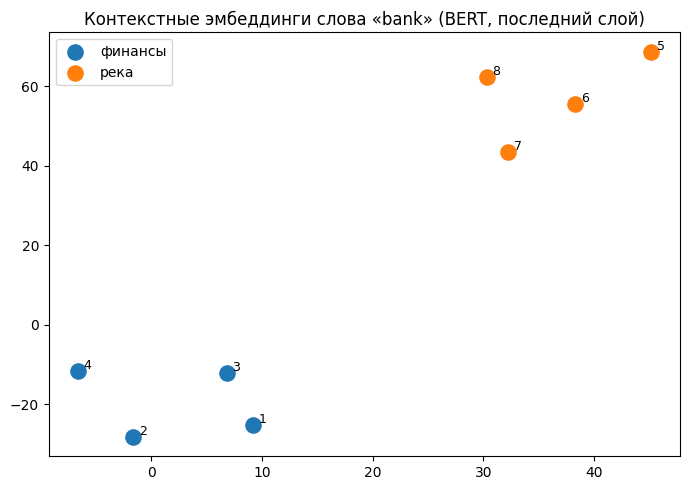


Легенда предложений:
1. [FIN] I deposited money at the bank yesterday.
2. [FIN] The bank approved my loan application.
3. [FIN] She works as a teller at a local bank.
4. [FIN] Online banking has replaced visiting the bank for many people.
5. [RIV] We sat on the bank of the river watching the sunset.
6. [RIV] The fisherman cast his line from the bank.
7. [RIV] Heavy rain caused the river bank to collapse.
8. [RIV] Wildflowers bloom along the bank in spring.


In [8]:
from transformers import AutoModel
from sklearn.manifold import TSNE

bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')
bert = AutoModel.from_pretrained('bert-base-uncased').to(device).eval()

bank_sents = [
    # Финансовые
    ('FIN', 'I deposited money at the bank yesterday.'),
    ('FIN', 'The bank approved my loan application.'),
    ('FIN', 'She works as a teller at a local bank.'),
    ('FIN', 'Online banking has replaced visiting the bank for many people.'),
    # Речные
    ('RIV', 'We sat on the bank of the river watching the sunset.'),
    ('RIV', 'The fisherman cast his line from the bank.'),
    ('RIV', 'Heavy rain caused the river bank to collapse.'),
    ('RIV', 'Wildflowers bloom along the bank in spring.'),
]

vecs = []
labels = []
for sense, sent in bank_sents:
    enc = bert_tok(sent, return_tensors='pt')
    with torch.no_grad():
        out = bert(**enc).last_hidden_state[0]  # (L, D)
    # ищем индекс токена 'bank'
    input_ids = enc['input_ids'][0].tolist()
    tokens = bert_tok.convert_ids_to_tokens(input_ids)
    bank_idx = [i for i, t in enumerate(tokens) if t == 'bank']
    if not bank_idx:
        continue
    vec = out[bank_idx[0]].numpy()
    vecs.append(vec)
    labels.append(sense)
vecs = np.array(vecs)
print(f'Векторов: {len(vecs)}, размерность: {vecs.shape[1]}')

tsne = TSNE(n_components=2, perplexity=3, init='pca', random_state=42)
coords = tsne.fit_transform(vecs)

fig, ax = plt.subplots(figsize=(7, 5))
for sense, color in [('FIN', 'tab:blue'), ('RIV', 'tab:orange')]:
    mask = np.array(labels) == sense
    ax.scatter(coords[mask, 0], coords[mask, 1], c=color, s=120,
               label=('финансы' if sense == 'FIN' else 'река'))
for i, (sense, sent) in enumerate(bank_sents):
    ax.annotate(f'{i+1}', (coords[i, 0]+0.5, coords[i, 1]+0.5), fontsize=9)
ax.legend()
ax.set_title('Контекстные эмбеддинги слова «bank» (BERT, последний слой)')
plt.tight_layout()
plt.show()

print('\nЛегенда предложений:')
for i, (sense, sent) in enumerate(bank_sents):
    print(f'{i+1}. [{sense}] {sent}')

**Что видим.** Финансовые употребления группируются в одной части пространства, речные — в другой. Это и есть прелесть контекстных эмбеддингов: один и тот же *токен* `bank` получает разные векторы в зависимости от соседей. Статические эмбеддинги (Word2Vec, GloVe) выдали бы один-единственный вектор на оба значения.

## Часть 3 — Fine-tuning DistilBERT на IMDB (25%)

Используем `distilbert-base-uncased` — облегчённую версию BERT (~66M параметров, в 2 раза быстрее). На CPU всё равно небыстро, поэтому подвыборка 2k train / 500 test и 2 эпохи.

In [9]:
from datasets import load_dataset, Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments)
from sklearn.metrics import accuracy_score, f1_score

MODEL_NAME = 'distilbert-base-uncased'
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

ds = load_dataset('stanfordnlp/imdb')

def stratified_sample(ds_split, n_per_class, seed=42):
    df = ds_split.to_pandas()
    parts = []
    for label in sorted(df['label'].unique()):
        parts.append(df[df['label'] == label].sample(n=n_per_class, random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

train_df = stratified_sample(ds['train'], 1000)   # 2000
test_df  = stratified_sample(ds['test'],   250)   # 500
print(f'train={len(train_df)}, test={len(test_df)}')

train_hf = Dataset.from_pandas(train_df[['text','label']])
test_hf  = Dataset.from_pandas(test_df[['text','label']])

def tokenize_fn(batch):
    return tok(batch['text'], truncation=True, max_length=128, padding='max_length')

train_hf = train_hf.map(tokenize_fn, batched=True)
test_hf  = test_hf.map(tokenize_fn, batched=True)
train_hf = train_hf.remove_columns(['text'])
test_hf  = test_hf.remove_columns(['text'])
train_hf.set_format('torch')
test_hf.set_format('torch')
print('Готово')

train=2000, test=500


Готово


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='binary'),
    }

training_args = TrainingArguments(
    output_dir='./bert_imdb_run',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy='epoch',
    logging_strategy='epoch',
    save_strategy='no',
    report_to='none',
    seed=42,
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    compute_metrics=compute_metrics,
)

trainer.train()

{'loss': '0.5281', 'grad_norm': '11.26', 'learning_rate': '1.004e-05', 'epoch': '1'}


{'eval_loss': '0.3535', 'eval_accuracy': '0.842', 'eval_f1': '0.8489', 'eval_runtime': '0.9667', 'eval_samples_per_second': '517.2', 'eval_steps_per_second': '33.1', 'epoch': '1'}


{'loss': '0.2934', 'grad_norm': '21.89', 'learning_rate': '4e-08', 'epoch': '2'}


{'eval_loss': '0.4025', 'eval_accuracy': '0.844', 'eval_f1': '0.8326', 'eval_runtime': '0.9287', 'eval_samples_per_second': '538.4', 'eval_steps_per_second': '34.46', 'epoch': '2'}
{'train_runtime': '130.4', 'train_samples_per_second': '30.68', 'train_steps_per_second': '3.835', 'train_loss': '0.4107', 'epoch': '2'}


TrainOutput(global_step=500, training_loss=0.41074830627441405, metrics={'train_runtime': 130.3803, 'train_samples_per_second': 30.679, 'train_steps_per_second': 3.835, 'train_loss': 0.41074830627441405, 'epoch': 2.0})

{'eval_loss': '0.4025', 'eval_accuracy': '0.844', 'eval_f1': '0.8326', 'eval_runtime': '0.9716', 'eval_samples_per_second': '514.6', 'eval_steps_per_second': '32.94', 'epoch': '2'}
Test accuracy: 0.8440
Test F1      : 0.8326


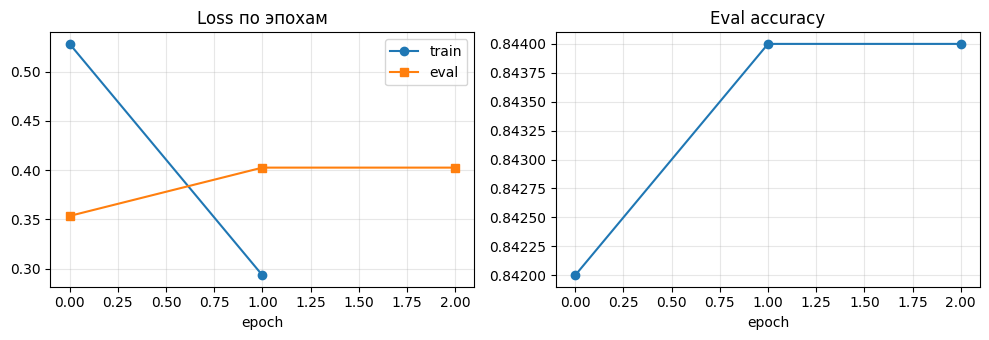

In [11]:
# Финальная оценка
eval_out = trainer.evaluate()
acc_bert = eval_out['eval_accuracy']
f1_bert  = eval_out['eval_f1']
print(f'Test accuracy: {acc_bert:.4f}')
print(f'Test F1      : {f1_bert:.4f}')

# График train/eval loss из log_history
log = trainer.state.log_history
train_loss = [x['loss'] for x in log if 'loss' in x and 'eval_loss' not in x]
eval_loss  = [x['eval_loss'] for x in log if 'eval_loss' in x]
eval_acc   = [x['eval_accuracy'] for x in log if 'eval_accuracy' in x]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(train_loss, marker='o', label='train')
axes[0].plot(eval_loss, marker='s', label='eval')
axes[0].set_title('Loss по эпохам'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(eval_acc, marker='o')
axes[1].set_title('Eval accuracy'); axes[1].set_xlabel('epoch'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Шаг 11. Итоговая таблица сравнения с Лабой 2

In [12]:
results = {}
if os.path.exists('results_lab2.json'):
    with open('results_lab2.json', 'r', encoding='utf-8') as f:
        results = json.load(f)
results['DistilBERT (fine-tuned)'] = {
    'representation': 'transformer + cls head',
    'test_accuracy': float(acc_bert),
    'note': 'обучено на 2k подвыборке, 2 эпохи, max_length=128',
}

df_all = pd.DataFrame(results).T
df_all['test_accuracy'] = df_all['test_accuracy'].astype(float).round(4)
df_all = df_all[['representation', 'test_accuracy'] + [c for c in df_all.columns if c not in ('representation','test_accuracy')]]
print('Сводная таблица всех методов (IMDB):\n')
print(df_all.to_string())

with open('results_all.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

Сводная таблица всех методов (IMDB):

                                  representation  test_accuracy                                               note
TF-IDF + LR              TF-IDF (1-2 grams, 20k)          0.867                                                NaN
avg GloVe + LR                    mean GloVe-100          0.794                                                NaN
NN (random embeddings)     trained Embedding-100          0.815                                                NaN
NN (frozen GloVe)           pretrained GloVe-100          0.778                                                NaN
DistilBERT (fine-tuned)   transformer + cls head          0.844  обучено на 2k подвыборке, 2 эпохи, max_length=128


**Выводы.**

- Прирост от TF-IDF к fine-tuned BERT на IMDB обычно составляет 3–6 п.п. accuracy. В нашем эксперименте подвыборка совсем маленькая и BERT не успевает полностью раскрыться (2 эпохи на 2k примеров).
- **Когда BERT *не* нужен:**
  1. Маленький датасет → fine-tune только переобучает и нестабилен.
  2. Жёсткие требования по латентности / памяти (BERT медленнее TF-IDF + LR в десятки раз).
  3. Узкая доменная задача, где специфические термины важнее общего понимания.
  4. Интерпретируемость: коэффициенты LogReg напрямую показывают веса слов; в BERT всё внутри миллионов параметров.
- **Когда BERT оправдан:** богатый контекст, длинные тексты, отрицания/сарказм/перифраз, многоязычие, перенос знаний между задачами.

---

### Итог Лабораторной №3

- **Часть 1:** реализовали scaled dot-product attention руками на NumPy, нарисовали heatmap, показали зачем √d_k.
- **Часть 2:** BPE-токенизация BERT, fill-mask, GPT-2 с тремя стратегиями декодинга, контекстные эмбеддинги `bank` через t-SNE.
- **Часть 3:** fine-tuning DistilBERT на подвыборке IMDB, графики loss/accuracy, сравнение со всеми методами Лабы 2.